In [3]:
!pip install -q kaggle
from google.colab import files
files.upload()

Saving data_praktikum_analisis_data - data_praktikum_analisis_data.csv to data_praktikum_analisis_data - data_praktikum_analisis_data.csv


{'data_praktikum_analisis_data - data_praktikum_analisis_data.csv': b'Order_ID,CustomerID,Order_Date,Product_Category,Quantity,Price_Per_Unit,Ad_Budget,Total_Sales\r\n1001,5039,2023-08-19,Books,4,1184000.0,982000.0,4736000.0\r\n1002,5029,2023-08-29,Fashion,5,1733000.0,3513000.0,8665000.0\r\n1003,5015,2023-02-21,Fashion,4,1767000.0,2117000.0,7068000.0\r\n1004,5043,2023-04-06,Fashion,2,512000.0,4384000.0,1024000.0\r\n1005,5008,2023-08-10,Home Decor,2,1820000.0,2625000.0,3640000.0\r\n1006,5021,2023-08-19,Books,5,1204000.0,4868000.0,6020000.0\r\n1007,5039,2023-08-25,Electronics,4,733000.0,3049000.0,2932000.0\r\n1008,5019,2023-05-23,Gadget,1,1431000.0,1197000.0,1431000.0\r\n1009,5023,2023-06-20,Electronics,5,989000.0,4127000.0,4945000.0\r\n1010,5011,2023-01-29,Gadget,2,787000.0,1791000.0,1574000.0\r\n1011,5011,2023-02-05,Electronics,2,1425000.0,1803000.0,2850000.0\r\n1012,5024,2023-01-13,Books,5,535000.0,256000.0,2675000.0\r\n1013,5036,2023-06-09,Gadget,4,694000.0,2789000.0,2776000.0\r\n101

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets list -s "ecommerce data"

ref                                                             title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  -------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
cclark/product-item-data                                        eCommerce Item Data                                    140589  2016-08-18 00:32:54.173000          18286        212  0.7058824        
mmohaiminulislam/ecommerce-data-analysis                        ECommerce Data Analysis                              17628279  2024-01-01 02:04:35.787000           9918         69  1                
mkechinov/ecommerce-behavior-data-from-multi-category-store     eCommerce behavior data from multi category store  4606720907  2019-12-09 20:43:39.273000          76371        852  1                
jocke

In [ ]:
!kaggle datasets download -d carrie1/ecommerce-data

Dataset URL: https://www.kaggle.com/datasets/carrie1/ecommerce-data
License(s): unknown
100% 7.20M/7.20M [00:00<00:00, 211MB/s]



In [ ]:
!unzip ecommerce-data.zip

Archive:  ecommerce-data.zip
  inflating: data.csv                


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data.csv', encoding='latin-1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [ ]:
df = df[df['Quantity'] > 0]

In [ ]:
df = df[df['UnitPrice'] > 0]

In [ ]:
df = df.dropna(subset=['CustomerID'])

In [ ]:
df['Total_Sales'] = df['Quantity'] * df['UnitPrice']

In [ ]:
df['Month'] = df['InvoiceDate'].dt.to_period('M').astype(str)

In [ ]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  float64       
 7   Country      397884 non-null  object        
 8   Total_Sales  397884 non-null  float64       
 9   Month        397884 non-null  object        
dtypes: datetime64[ns](1), float64(3), int64(1), object(5)
memory usage: 33.4+ MB


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total_Sales,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12


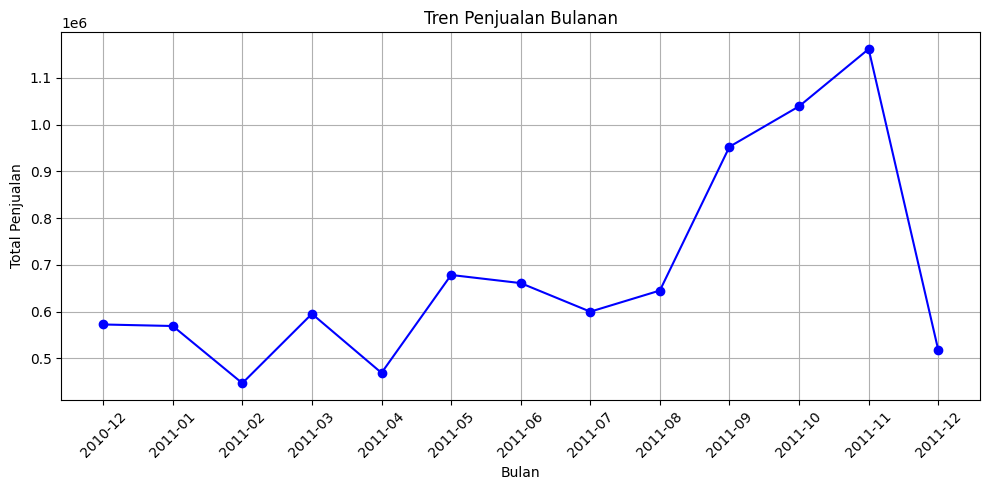

In [ ]:
monthly_sales = df.groupby('Month')['Total_Sales'].sum()

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', color='b')
plt.title('Tren Penjualan Bulanan')
plt.xlabel('Bulan')
plt.ylabel('Total Penjualan')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

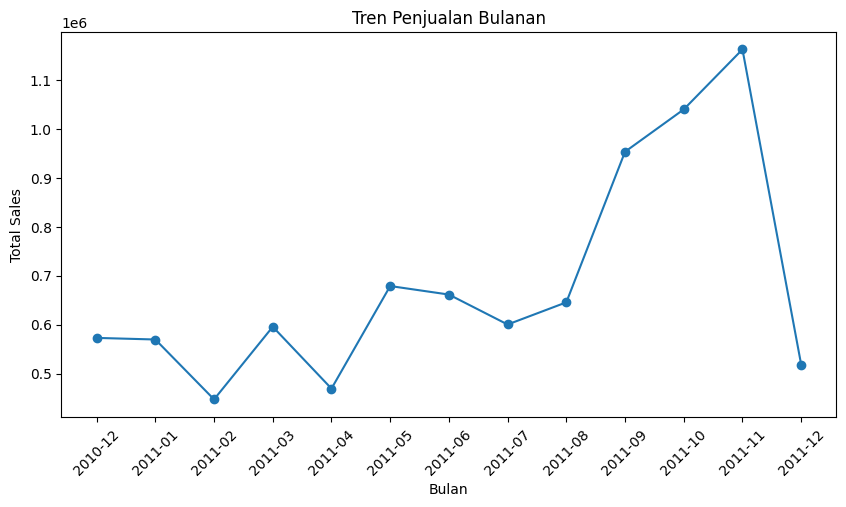

In [ ]:
import matplotlib.pyplot as plt

# Hitung total penjualan per bulan
monthly_sales = df.groupby('Month')['Total_Sales'].sum()

# Buat grafik
plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.xticks(rotation=45)

plt.title('Tren Penjualan Bulanan')
plt.xlabel('Bulan')
plt.ylabel('Total Sales')

plt.show()

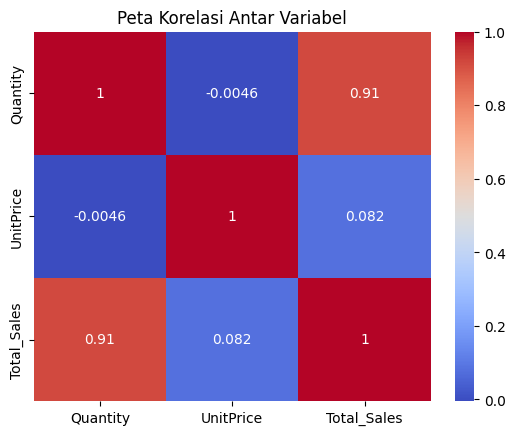

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation = df[['Quantity', 'UnitPrice', 'Total_Sales']].corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Peta Korelasi Antar Variabel')
plt.show()

In [4]:
from google.colab import files
files.upload()

Saving data_praktikum_analisis_data - data_praktikum_analisis_data.csv to data_praktikum_analisis_data - data_praktikum_analisis_data (1).csv


{'data_praktikum_analisis_data - data_praktikum_analisis_data (1).csv': b'Order_ID,CustomerID,Order_Date,Product_Category,Quantity,Price_Per_Unit,Ad_Budget,Total_Sales\r\n1001,5039,2023-08-19,Books,4,1184000.0,982000.0,4736000.0\r\n1002,5029,2023-08-29,Fashion,5,1733000.0,3513000.0,8665000.0\r\n1003,5015,2023-02-21,Fashion,4,1767000.0,2117000.0,7068000.0\r\n1004,5043,2023-04-06,Fashion,2,512000.0,4384000.0,1024000.0\r\n1005,5008,2023-08-10,Home Decor,2,1820000.0,2625000.0,3640000.0\r\n1006,5021,2023-08-19,Books,5,1204000.0,4868000.0,6020000.0\r\n1007,5039,2023-08-25,Electronics,4,733000.0,3049000.0,2932000.0\r\n1008,5019,2023-05-23,Gadget,1,1431000.0,1197000.0,1431000.0\r\n1009,5023,2023-06-20,Electronics,5,989000.0,4127000.0,4945000.0\r\n1010,5011,2023-01-29,Gadget,2,787000.0,1791000.0,1574000.0\r\n1011,5011,2023-02-05,Electronics,2,1425000.0,1803000.0,2850000.0\r\n1012,5024,2023-01-13,Books,5,535000.0,256000.0,2675000.0\r\n1013,5036,2023-06-09,Gadget,4,694000.0,2789000.0,2776000.0\r\

In [5]:
import pandas as pd

df = pd.read_csv('data_praktikum_analisis_data - data_praktikum_analisis_data.csv')
df.head()

,Order_ID,CustomerID,Order_Date,Product_Category,Quantity,Price_Per_Unit,Ad_Budget,Total_Sales
0,1001,5039,2023-08-19,Books,4,1184000.0,982000.0,4736000.0
1,1002,5029,2023-08-29,Fashion,5,1733000.0,3513000.0,8665000.0
2,1003,5015,2023-02-21,Fashion,4,1767000.0,2117000.0,7068000.0
3,1004,5043,2023-04-06,Fashion,2,512000.0,4384000.0,1024000.0
4,1005,5008,2023-08-10,Home Decor,2,1820000.0,2625000.0,3640000.0


In [ ]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          150 non-null    int64  
 1   CustomerID        150 non-null    int64  
 2   Order_Date        150 non-null    object 
 3   Product_Category  150 non-null    object 
 4   Quantity          150 non-null    int64  
 5   Price_Per_Unit    150 non-null    float64
 6   Ad_Budget         150 non-null    float64
 7   Total_Sales       143 non-null    float64
dtypes: float64(3), int64(3), object(2)
memory usage: 9.5+ KB


,0
Order_ID,0
CustomerID,0
Order_Date,0
Product_Category,0
Quantity,0
Price_Per_Unit,0
Ad_Budget,0
Total_Sales,7


In [ ]:
# ubah tanggal
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# hapus data aneh
df = df[df['Price_Per_Unit'] > 0]
df = df[df['Quantity'] > 0]
df = df[df['Ad_Budget'] > 0]

In [ ]:
df['Month'] = df['Order_Date'].dt.to_period('M').astype(str)

In [ ]:
df['Total_Sales'] = df['Quantity'] * df['Price_Per_Unit']

In [ ]:
df.isnull().sum()

,0
Order_ID,0
CustomerID,0
Order_Date,0
Product_Category,0
Quantity,0
Price_Per_Unit,0
Ad_Budget,0
Total_Sales,0
Month,0


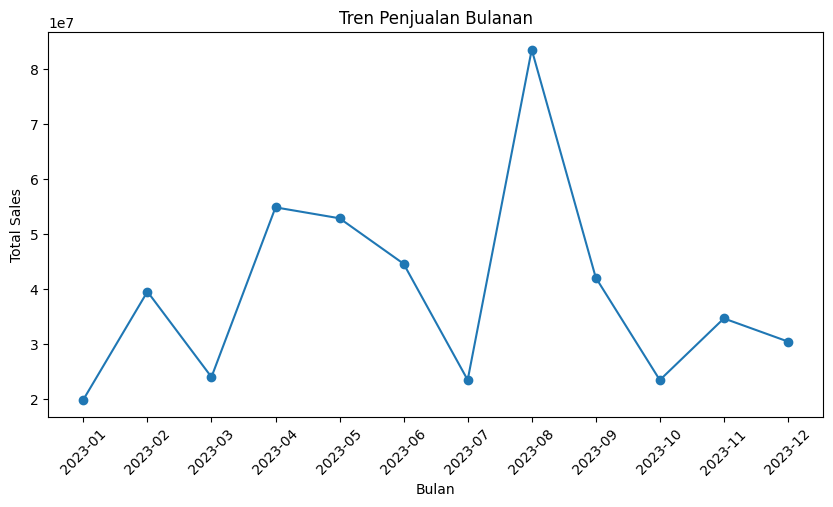

In [ ]:
import matplotlib.pyplot as plt

monthly_sales = df.groupby('Month')['Total_Sales'].sum()

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.xticks(rotation=45)

plt.title('Tren Penjualan Bulanan')
plt.xlabel('Bulan')
plt.ylabel('Total Sales')

plt.show()

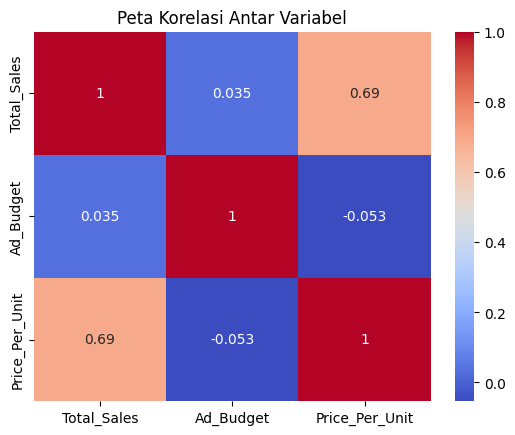

In [ ]:
import seaborn as sns

correlation = df[['Total_Sales', 'Ad_Budget', 'Price_Per_Unit']].corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Peta Korelasi Antar Variabel')
plt.show()

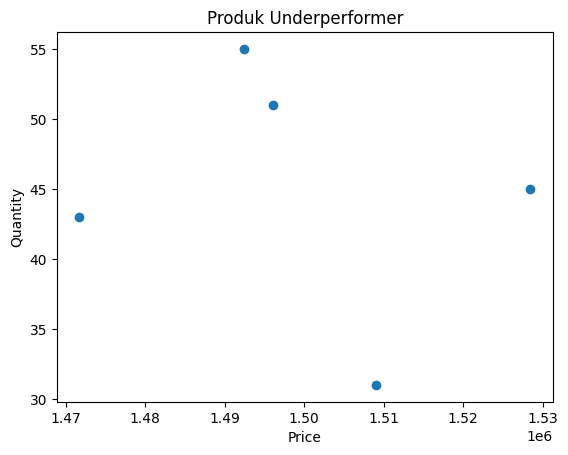

In [6]:
avg_price = df['Price_Per_Unit'].mean()

under = df[df['Price_Per_Unit'] > avg_price]

under_group = under.groupby('Product_Category').agg({
    'Quantity': 'sum',
    'Price_Per_Unit': 'mean'
}).reset_index()

import matplotlib.pyplot as plt

plt.scatter(under_group['Price_Per_Unit'], under_group['Quantity'])
plt.xlabel('Price')
plt.ylabel('Quantity')
plt.title('Produk Underperformer')
plt.show()

In [8]:
import pandas as pd
import datetime as dt

# ubah ke datetime
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# buat snapshot date
snapshot_date = df['Order_Date'].max() + dt.timedelta(days=1)

# RFM
rfm = df.groupby('CustomerID').agg({
    'Order_Date': lambda x: (snapshot_date - x.max()).days,
    'Order_ID': 'count',
    'Total_Sales': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
5001,213,4,8562000.0
5002,77,4,6931000.0
5003,118,3,9433000.0
5004,196,3,15368000.0
5005,23,2,9105000.0


In [9]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

rfm['RFM_Group'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

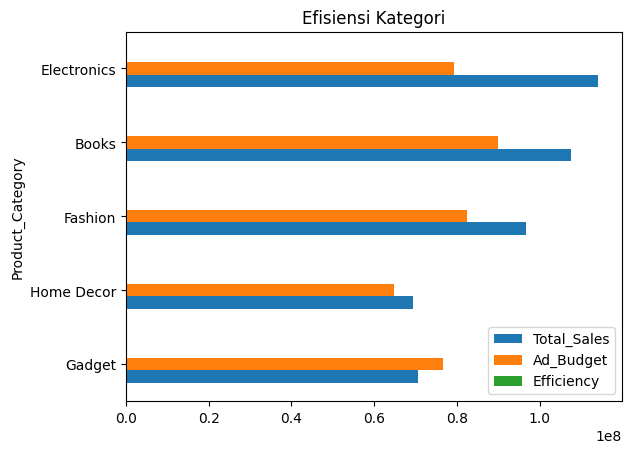

In [10]:
category = df.groupby('Product_Category').agg({
    'Total_Sales': 'sum',
    'Ad_Budget': 'sum'
})

category['Efficiency'] = category['Total_Sales'] / category['Ad_Budget']

category = category.sort_values('Efficiency')

category.plot(kind='barh')
plt.title('Efisiensi Kategori')
plt.show()

In [11]:
median_ad = df['Ad_Budget'].median()

high = df[df['Ad_Budget'] > median_ad]
low = df[df['Ad_Budget'] <= median_ad]

print("Rata-rata sales (Iklan Tinggi):", high['Total_Sales'].mean())
print("Rata-rata sales (Iklan Rendah):", low['Total_Sales'].mean())

Rata-rata sales (Iklan Tinggi): 3156275.362318841
Rata-rata sales (Iklan Rendah): 3247216.2162162163


In [13]:
df['Total_Sales'] = df['Quantity'] * df['Price_Per_Unit']

In [14]:
df.isnull().sum()

,0
Order_ID,0
CustomerID,0
Order_Date,0
Product_Category,0
Quantity,0
Price_Per_Unit,0
Ad_Budget,0
Total_Sales,0


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[['Ad_Budget']]
y = df['Total_Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print("Koefisien:", model.coef_[0])
print("R2 Score:", model.score(X_test, y_test))

Koefisien: 0.08953632188546166
R2 Score: -0.0727826335616284
